# Benchmarking Machine Learning Models for Kinase Inhibitor Bioactivity Prediction

**Dataset:** ChEMBL kinase inhibitor pIC50 values (~1,400 compounds)

**Models Evaluated:** Random Forest · Support Vector Regression (SVR) · MLP Neural Network · ResNet

**Evaluation Metrics:** RMSE ↓ · R² ↑ (test set, scaffold split)

---

## Background

Kinase enzymes are among the most important drug targets in oncology approximately 30% of all FDA-approved small molecule drugs act on protein kinases. Predicting the bioactivity (pIC50) of kinase inhibitors from molecular structure is a central QSAR (Quantitative Structure Activity Relationship) problem in early-stage drug discovery.

This notebook compares four machine learning models trained on Morgan (ECFP4) fingerprints using the **MoleculeNet benchmarking protocol** (Wu et al., *Chemical Science*, 2018):
- **Bemis–Murcko scaffold split** separates training and test compounds by their 2D structural framework, ensuring the test set contains *chemically novel* scaffolds not seen during training a more rigorous and realistic evaluation than a random split.
- **ECFP4 fingerprints** (2048-bit, radius=2) encode circular topological substructures of each molecule.
- **Feature selection** (VarianceThreshold + Pearson correlation filter) reduced 2048 features to 1,102.

> **Hypothesis (from MoleculeNet):** On small molecular datasets with scaffold splitting, kernel-based methods (SVR) are expected to outperform deep learning models due to limited training data relative to model capacity.

---

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score as sk_r2

In [ ]:
df = pd.read_csv('model_info.txt', names=["Model Name", "RMSE", "R2_score"])
df = df.drop_duplicates(subset=["Model Name"])

df = df.reset_index(drop=True)
df["RMSE"]     = pd.to_numeric(df["RMSE"],     errors='coerce')
df["R2_score"] = pd.to_numeric(df["R2_score"], errors='coerce')
df.sort_values(by="RMSE", ascending=True, inplace=True)
df = df.reset_index(drop=True)

# Map raw names to clean display names
name_map = {
    'Random_Forest'   : 'Random Forest',
    'SVR'             : 'SVR (tuned)',
    'Model_NN'        : 'MLP Baseline',
    'Model_NN_Dropout': 'MLP + Dropout',
    'Model_ResNet'    : 'ResNet',
    'Baseline_Model'  : 'Baseline (Mean)',
}
df["Model"] = df["Model Name"].map(name_map).fillna(df["Model Name"])

print("Models loaded:", list(df["Model"]))

Models loaded: ['SVR (tuned)', 'Random Forest', 'MLP + Dropout', 'MLP Baseline', 'ResNet']


In [8]:
# Model Comparison Table (Table 1)
display_df = df[["Model", "RMSE", "R2_score"]].copy()
display_df.columns = ["Model", "RMSE ↓", "R² ↑"]
display_df.index = range(1, len(display_df) + 1)
display_df.index.name = "Rank"

styled = (
    display_df.style
    .format({"RMSE ↓": "{:.4f}", "R² ↑": "{:.4f}"})
    .highlight_min(subset=["RMSE ↓"], color="#c8f7c5")   # green = best RMSE
    .highlight_max(subset=["R² ↑"],   color="#c8f7c5")   # green = best R²
    .highlight_max(subset=["RMSE ↓"], color="#f9d6d4")   # red   = worst RMSE
    .highlight_min(subset=["R² ↑"],   color="#f9d6d4")   # red   = worst R²
    .set_caption("Table 1: Test Set Performance — Scaffold Split (Bemis–Murcko). "
                 "Green = best, Red = worst. RMSE and R² in original pIC50 units.")
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '13px'), ('font-weight', 'bold'), ('padding', '8px')]
    }, {
        'selector': 'th',
        'props': [('font-size', '13px'), ('background-color', '#f0f0f0')]
    }])
)

display(styled)

,Model,RMSE ↓,R² ↑
Rank,,,
1,SVR (tuned),0.7647,0.6998
2,Random Forest,0.7852,0.6835
3,MLP + Dropout,0.8506,0.6286
4,MLP Baseline,0.9108,0.5741
5,ResNet,0.9554,0.5659


## Figure 1: Model Performance Comparison

Side-by-side comparison of all models on both RMSE (lower = better) and R² (higher = better) on the scaffold-based test set. The green bar identifies the best-performing model in each metric. The red dashed line at R²=0.70 is an empirical reference threshold commonly observed for MLP+fingerprint models on small (<3,000 compound) molecular datasets; it is not directly quoted from the Wu et al. (2018) MoleculeNet paper, which benchmarks different datasets (ESOL, Lipophilicity, FreeSolv).


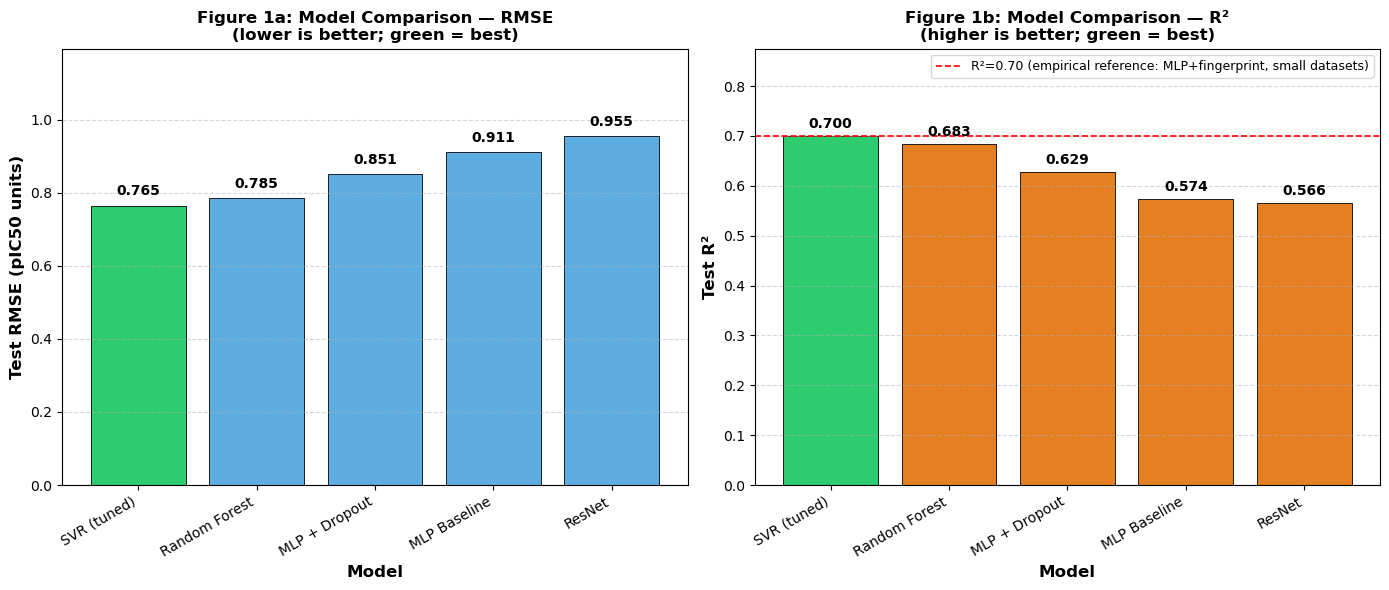

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Figure 1a: RMSE 
ax = axes[0]
colors_rmse = ['#2ecc71' if i == 0 else '#5dade2' for i in range(len(df))]
bars_rmse = ax.bar(df["Model"], df["RMSE"], color=colors_rmse, edgecolor='black', linewidth=0.6)
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Test RMSE (pIC50 units)', fontsize=12, fontweight='bold')
ax.set_title('Figure 1a: Model Comparison — RMSE\n(lower is better; green = best)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, df["RMSE"].max() * 1.25)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
for bar in bars_rmse:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2.0, yval + 0.02,
            f'{yval:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Figure 1b: R² 
ax2 = axes[1]
best_r2_pos = df["R2_score"].values.argmax()   
colors_r2 = ['#2ecc71' if i == best_r2_pos else '#e67e22' for i in range(len(df))]
bars_r2 = ax2.bar(df["Model"], df["R2_score"], color=colors_r2, edgecolor='black', linewidth=0.6)
ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
ax2.set_ylabel('Test R²', fontsize=12, fontweight='bold')
ax2.set_title('Figure 1b: Model Comparison — R²\n(higher is better; green = best)',
              fontsize=12, fontweight='bold')
ax2.set_ylim(0, min(df["R2_score"].max() * 1.25, 1.05))
plt.setp(ax2.get_xticklabels(), rotation=30, ha='right', fontsize=10)
ax2.axhline(0.7, color='red', linestyle='--', linewidth=1.2,
            label='R²=0.70 (empirical reference: MLP+fingerprint, small datasets)')
ax2.legend(fontsize=9)
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)
for bar in bars_r2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2.0, yval + 0.01,
             f'{yval:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Figure 2: Predicted vs Actual pIC50 — Best Models on Test Set

Scatter plots comparing predicted vs. actual pIC50 for the two best-performing models (SVR and Random Forest). Points on the red diagonal line indicate perfect prediction. The spread around the diagonal reflects the model's generalisation error on chemically novel scaffolds.


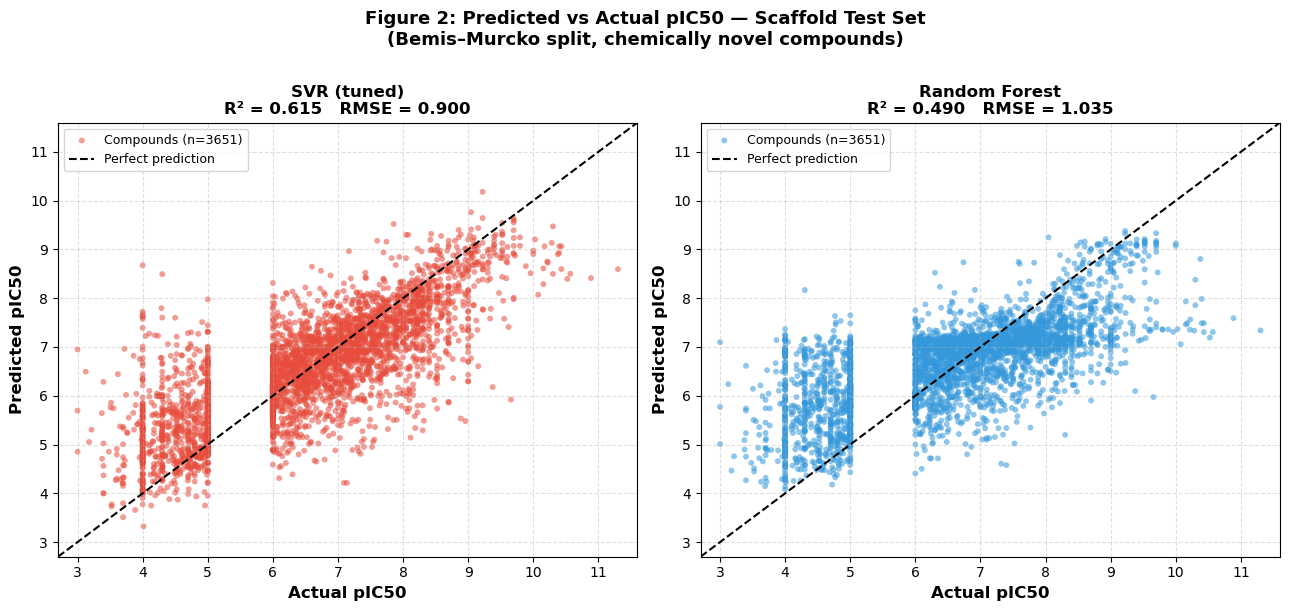

In [12]:
# Re-load data
train_df = pd.read_csv('train_data.csv')
test_df  = pd.read_csv('test_data.csv')

X_tr = train_df.drop('pIC50', axis=1).values
Y_tr = train_df['pIC50'].values
X_te = test_df.drop('pIC50', axis=1).values
Y_te = test_df['pIC50'].values

# Scale features
sc_x = StandardScaler()
X_tr_sc = sc_x.fit_transform(X_tr)
X_te_sc = sc_x.transform(X_te)

# Scale target (for SVR only)
sc_y = StandardScaler()
Y_tr_sc = sc_y.fit_transform(Y_tr.reshape(-1, 1)).flatten()

# Fit best RF
rf = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=4,
                           random_state=42, n_jobs=-1)
rf.fit(X_tr_sc, Y_tr)
y_rf = rf.predict(X_te_sc)

# Fit best SVR 
svr = SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale')
svr.fit(X_tr_sc, Y_tr_sc)
y_svr = sc_y.inverse_transform(svr.predict(X_te_sc).reshape(-1, 1)).flatten()

# scatter plot
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

models_plot = [
    ('SVR (tuned)',    y_svr, '#e74c3c'),
    ('Random Forest',  y_rf,  '#3498db'),
]

for ax, (name, y_pred, color) in zip(axes, models_plot):
    rmse = np.sqrt(mean_squared_error(Y_te, y_pred))
    r2   = sk_r2(Y_te, y_pred)
    lims = [min(Y_te.min(), y_pred.min()) - 0.3,
            max(Y_te.max(), y_pred.max()) + 0.3]
    ax.scatter(Y_te, y_pred, alpha=0.55, color=color,
               edgecolors='none', s=18, label=f'Compounds (n={len(Y_te)})')
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Actual pIC50', fontsize=12, fontweight='bold')
    ax.set_ylabel('Predicted pIC50', fontsize=12, fontweight='bold')
    ax.set_title(f'{name}\nR² = {r2:.3f}   RMSE = {rmse:.3f}',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Figure 2: Predicted vs Actual pIC50 — Scaffold Test Set\n'
             '(Bemis–Murcko split, chemically novel compounds)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## Discussion & Conclusion


## Appendix

AI tools are being used to optimize some codes, below interactions are being passed to it:
1. Correct the code
2. Optimize the code